In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import time

torch.manual_seed(99)
np.random.seed(99)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


In [3]:
def soliton(x, t, c, x0):
    arg = (torch.sqrt(torch.tensor(float(c))) / 2.0) * (x - c * t - x0)
    return (c / 2.0) / torch.cosh(arg) ** 2

In [4]:
def make_config(N, d=10.0, T=5.0):
    speeds = [1.5 + 0.5 * (N - 1 - k) for k in range(N)]
    x0s    = [((N - 1) / 2.0 - k) * d  for k in range(N)]
    c_max   = speeds[0]
    x_left  = x0s[-1] - 10.0
    x_right = x0s[0]  + c_max * T + 15.0
    return speeds, x0s, (x_left, x_right)

In [5]:
def n_soliton(x, t, speeds, x0s):
    u = torch.zeros_like(x, dtype=torch.float32)
    for c, x0 in zip(speeds, x0s):
        u = u + soliton(x, t, float(c), float(x0))
    return u

In [6]:
class PINN(torch.nn.Module):
    def __init__(self, width=50):
        super().__init__()
        # 6 hidden layers of `width` neurons each
        sizes = [2] + [width] * 6 + [1]
        self.layers = torch.nn.ModuleList(
            [torch.nn.Linear(sizes[i], sizes[i+1]) for i in range(len(sizes)-1)]
        )
        for layer in self.layers:
            torch.nn.init.xavier_normal_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

    def forward(self, x, t):
        z = torch.cat([x, t], dim=1)
        for layer in self.layers[:-1]:
            z = torch.tanh(layer(z))
        return self.layers[-1](z)

# quick check
for w in [50, 75, 100]:
    m = PINN(width=w)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'width={w}: {n_params:,} parameters')

width=50: 12,951 parameters
width=75: 28,801 parameters
width=100: 50,901 parameters


In [7]:
def derivatives(model, x, t):
    u     = model(x, t)
    u_x   = torch.autograd.grad(u,    x,  grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_t   = torch.autograd.grad(u,    t,  grad_outputs=torch.ones_like(u),   create_graph=True)[0]
    u_xx  = torch.autograd.grad(u_x,  x,  grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, x,  grad_outputs=torch.ones_like(u_xx),create_graph=True)[0]
    return u, u_t, u_x, u_xxx

In [8]:
def pde_loss(model, x, t):
    u, u_t, u_x, u_xxx = derivatives(model, x, t)
    res = u_t + 6.0 * u * u_x + u_xxx
    return torch.mean(res ** 2)

In [9]:
def ic_loss(model, x_ic, t_ic, exact_fn):
    u_pred  = model(x_ic, t_ic)
    u_exact = exact_fn(x_ic.squeeze(), t_ic.squeeze()).unsqueeze(1)
    return torch.mean((u_pred - u_exact) ** 2)

In [10]:
def bc_loss(model, x_bc, t_bc):
    return torch.mean(model(x_bc, t_bc) ** 2)

In [11]:
def data_loss(model, x_d, t_d, u_d):
    return torch.mean((model(x_d, t_d) - u_d) ** 2)

In [12]:
def total_loss(model, batch, exact_fn):
    x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_d, t_d, u_d = batch
    lp = pde_loss (model, x_pde, t_pde)
    li = ic_loss  (model, x_ic,  t_ic, exact_fn)
    lb = bc_loss  (model, x_bc,  t_bc)
    ld = data_loss(model, x_d,   t_d,  u_d)
    return lp + li + lb + ld, lp, li, lb, ld

In [13]:
def build_data(speeds, x0s, domain, T, device):
    xl, xr = domain
    width  = xr - xl
    scale  = width / 60.0   # baseline 3-soliton domain ~60 units

    n_pde  = int(20000 * scale)
    n_data = int(400   * scale)
    n_ic   = max(500,  int(500 * scale))
    n_bc   = 100

    x_pde = (xl + width * torch.rand(n_pde, 1)).to(device).requires_grad_(True)
    t_pde = (T  *         torch.rand(n_pde, 1)).to(device).requires_grad_(True)

    x_d = (xl + width * torch.rand(n_data, 1)).to(device)
    t_d = (T  *         torch.rand(n_data, 1)).to(device)
    efn = lambda x, t: n_soliton(x, t, speeds, x0s)
    u_d = efn(x_d.squeeze(), t_d.squeeze()).unsqueeze(1).to(device)

    x_ic = torch.linspace(xl, xr, n_ic).view(-1, 1).to(device).requires_grad_(True)
    t_ic = torch.zeros(n_ic, 1).to(device).requires_grad_(True)

    t_bc_v     = torch.linspace(0, T, n_bc).view(-1, 1).to(device)
    x_bc_left  = torch.full((n_bc, 1), float(xl)).to(device).requires_grad_(True)
    x_bc_right = torch.full((n_bc, 1), float(xr)).to(device).requires_grad_(True)
    x_bc = torch.cat([x_bc_left,  x_bc_right], dim=0)
    t_bc = torch.cat([t_bc_v, t_bc_v], dim=0).requires_grad_(True)

    print(f'  PDE: {n_pde:,}  |  Data: {n_data:,}  |  IC: {n_ic:,}  |  BC: {2*n_bc}')
    return (x_pde, t_pde, x_ic, t_ic, x_bc, t_bc, x_d, t_d, u_d), efn

In [14]:
def compute_l2(model, exact_fn, domain, T, nx=500, nt=100):
    xl, xr = domain
    x_g = torch.linspace(xl, xr, nx)
    t_g = torch.linspace(0,   T,  nt)
    X, TT = torch.meshgrid(x_g, t_g, indexing='ij')
    xf = X.reshape(-1, 1).to(device)
    tf = TT.reshape(-1, 1).to(device)
    with torch.no_grad():
        u_pred = model(xf, tf).cpu().numpy().reshape(nx, nt)
    u_exact = exact_fn(X.reshape(-1), TT.reshape(-1)).numpy().reshape(nx, nt)
    return float(np.sqrt(np.sum((u_pred - u_exact)**2)) / np.sqrt(np.sum(u_exact**2)))

In [15]:
def train_model(N, speeds, x0s, domain, width=50, T=5.0, n_adam=15000, n_lbfgs=2000):
    print(f'\n{"="*70}')
    print(f'  N={N}  |  width={width}  |  6x{width} architecture')
    print(f'  domain=[{domain[0]:.1f}, {domain[1]:.1f}]  |  speeds={[round(c,1) for c in speeds]}')
    print(f'{"="*70}')

    batch, exact_fn = build_data(speeds, x0s, domain, T, device)
    model = PINN(width=width).to(device)

    n_params = sum(p.numel() for p in model.parameters())
    print(f'  params: {n_params:,}')

    t0 = time.time()

    # Adam
    opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = {k: [] for k in ('total', 'pde', 'ic', 'bc', 'data')}

    for i in range(n_adam):
        opt_adam.zero_grad()
        loss, lp, li, lb, ld = total_loss(model, batch, exact_fn)
        loss.backward()
        opt_adam.step()
        hist['total'].append(loss.item())
        hist['pde'].append(lp.item())
        hist['ic'].append(li.item())
        hist['bc'].append(lb.item())
        hist['data'].append(ld.item())
        if i % 1000 == 0:
            print(f'  Adam {i:5d} | Total={loss.item():.6f}  PDE={lp.item():.6f}  IC={li.item():.6f}  Data={ld.item():.6f}')

    t_adam = time.time() - t0
    l2_adam = compute_l2(model, exact_fn, domain, T)
    final_adam_loss = hist['total'][-1]
    print(f'  >> Adam done in {t_adam:.1f}s  |  L2={l2_adam*100:.4f}%  |  loss={final_adam_loss:.6f}')

    # L-BFGS
    t1 = time.time()
    opt_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1, max_iter=20, history_size=50)

    for i in range(n_lbfgs):
        def closure():
            opt_lbfgs.zero_grad()
            loss, *_ = total_loss(model, batch, exact_fn)
            loss.backward()
            return loss
        opt_lbfgs.step(closure)
        if i % 200 == 0:
            loss, *_ = total_loss(model, batch, exact_fn)
            print(f'  LBFGS {i:4d} | Total={loss.item():.8f}')

    t_lbfgs = time.time() - t1
    l2_final = compute_l2(model, exact_fn, domain, T)
    loss_final, *_ = total_loss(model, batch, exact_fn)
    print(f'  >> LBFGS done in {t_lbfgs:.1f}s  |  L2={l2_final*100:.4f}%  |  loss={loss_final.item():.8f}')

    return model, exact_fn, hist, {
        'N': N,
        'width': width,
        'n_params': n_params,
        'l2_adam': l2_adam,
        'l2_final': l2_final,
        'final_adam_loss': final_adam_loss,
        'final_lbfgs_loss': loss_final.item(),
        'time_adam': t_adam,
        'time_lbfgs': t_lbfgs,
        'domain': domain,
    }

In [16]:
T_END = 5.0

# configs to run: (N, width)
# baseline 6x50 results for N=9 and N=12 come from the scaling notebook
# this sweep tests whether more width fixes N=12
sweep_configs = [
    (9,  100),   # does 6x100 push N=9 below 5%?
    (12,  75),   # middle data point at N=12
    (12, 100),   # key test: does 6x100 rescue N=12?
]

sweep_results = {}

for N, width in sweep_configs:
    speeds, x0s, domain = make_config(N, T=T_END)
    model, efn, hist, rec = train_model(N, speeds, x0s, domain, width=width, T=T_END)
    key = f'N{N}_w{width}'
    sweep_results[key] = dict(model=model, exact_fn=efn, hist=hist, **rec)
    # save checkpoint so you don't have to retrain
    torch.save(model.state_dict(), f'checkpoint_{key}.pt')
    print(f'  saved: checkpoint_{key}.pt\n')


  N=9  |  width=100  |  6x100 architecture
  domain=[-50.0, 82.5]  |  speeds=[5.5, 5.0, 4.5, 4.0, 3.5, 3.0, 2.5, 2.0, 1.5]
  PDE: 44,166  |  Data: 883  |  IC: 1,104  |  BC: 200
  params: 50,901


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Adam     0 | Total=0.993150  PDE=0.012777  IC=0.451158  Data=0.436798
  Adam  1000 | Total=0.357284  PDE=0.013583  IC=0.164612  Data=0.178443
  Adam  2000 | Total=0.160266  PDE=0.007245  IC=0.087369  Data=0.065647
  Adam  3000 | Total=0.026609  PDE=0.008766  IC=0.006994  Data=0.010784
  Adam  4000 | Total=0.006729  PDE=0.001497  IC=0.001774  Data=0.003456
  Adam  5000 | Total=0.022576  PDE=0.004181  IC=0.007503  Data=0.010886
  Adam  6000 | Total=0.000909  PDE=0.000442  IC=0.000175  Data=0.000290
  Adam  7000 | Total=0.002541  PDE=0.000481  IC=0.000870  Data=0.001188
  Adam  8000 | Total=0.015345  PDE=0.012768  IC=0.001081  Data=0.001197
  Adam  9000 | Total=0.019480  PDE=0.003818  IC=0.006346  Data=0.009015
  Adam 10000 | Total=0.000888  PDE=0.000239  IC=0.000267  Data=0.000379
  Adam 11000 | Total=0.008928  PDE=0.001858  IC=0.002887  Data=0.004177
  Adam 12000 | Total=0.009236  PDE=0.002260  IC=0.002915  Data=0.004061
  Adam 13000 | Total=0.000419  PDE=0.000208  IC=0.000083  Data=0

In [17]:
# hardcode the 6x50 baselines from your scaling notebook results here
# fill these in from your actual run
baseline = {
    'N9_w50':  {'l2_adam': None, 'l2_final': None},   # e.g. fill with 0.0234, 0.0078
    'N12_w50': {'l2_adam': None, 'l2_final': None},   # e.g. fill with 0.29, 0.33
}

print(f'\n{"="*72}')
print(f"{'Config':<12} | {'N':>3} | {'Width':>5} | {'Params':>8} | {'L2 Adam':>10} | {'L2 Final':>10}")
print('-'*72)

# baselines first (manual)
for label, vals in baseline.items():
    N = int(label[1:label.index('_')])
    w = 50
    if vals['l2_final'] is not None:
        print(f'{label:<12} | {N:>3} | {w:>5} | {"~15k":>8} | {vals["l2_adam"]*100:>9.4f}% | {vals["l2_final"]*100:>9.4f}%')
    else:
        print(f'{label:<12} | {N:>3} | {w:>5} | {"~15k":>8} | {"?":>10} | {"?":>10}')

# sweep results
for key, r in sweep_results.items():
    print(f'{key:<12} | {r["N"]:>3} | {r["width"]:>5} | {r["n_params"]:>8,} | {r["l2_adam"]*100:>9.4f}% | {r["l2_final"]*100:>9.4f}%')

print('='*72)


Config       |   N | Width |   Params |    L2 Adam |   L2 Final
------------------------------------------------------------------------
N9_w50       |   9 |    50 |     ~15k |          ? |          ?
N12_w50      |  12 |    50 |     ~15k |          ? |          ?
N9_w100      |   9 |   100 |   50,901 |   26.7244% |    0.6174%
N12_w75      |  12 |    75 |   28,801 |   25.7965% |   24.3948%
N12_w100     |  12 |   100 |   50,901 |   17.8739% |    0.8554%


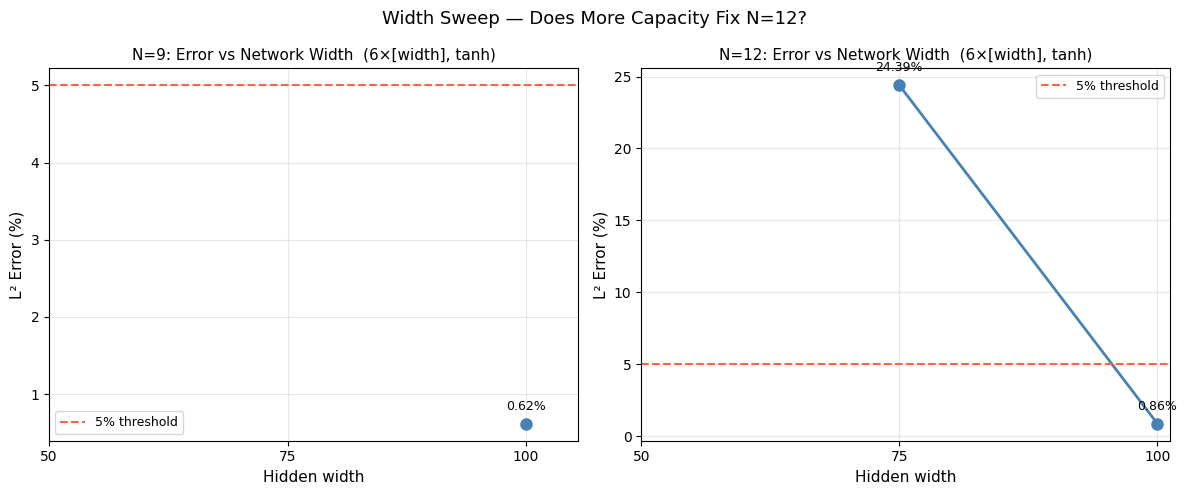

saved: width_sweep_result.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, N in zip(axes, [9, 12]):
    widths, l2s = [], []

    # add the 6x50 baseline if you filled it in
    b_key = f'N{N}_w50'
    if baseline[b_key]['l2_final'] is not None:
        widths.append(50)
        l2s.append(baseline[b_key]['l2_final'] * 100)

    # add sweep results for this N
    for key, r in sweep_results.items():
        if r['N'] == N:
            widths.append(r['width'])
            l2s.append(r['l2_final'] * 100)

    widths, l2s = zip(*sorted(zip(widths, l2s)))

    ax.plot(widths, l2s, 'o-', color='steelblue', linewidth=2, markersize=8)
    ax.axhline(5.0, color='tomato', linestyle='--', linewidth=1.5, label='5% threshold')
    for w, e in zip(widths, l2s):
        ax.annotate(f'{e:.2f}%', (w, e), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
    ax.set_xlabel('Hidden width', fontsize=11)
    ax.set_ylabel('L² Error (%)', fontsize=11)
    ax.set_title(f'N={N}: Error vs Network Width  (6×[width], tanh)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([50, 75, 100])

plt.suptitle('Width Sweep — Does More Capacity Fix N=12?', fontsize=13)
plt.tight_layout()
plt.savefig('width_sweep_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: width_sweep_result.png')

In [19]:
print('\n--- INTERPRETATION ---')
for N in [9, 12]:
    w50_final = baseline[f'N{N}_w50']['l2_final']
    w100_key  = f'N{N}_w100'
    if w100_key in sweep_results:
        w100_final = sweep_results[w100_key]['l2_final']
        if w50_final is not None:
            drop = (w50_final - w100_final) / w50_final * 100
            print(f'N={N}: 6x50 → {w50_final*100:.2f}%,  6x100 → {w100_final*100:.2f}%  (drop: {drop:.1f}%)')
            if w100_final < 0.05:
                print(f'  => 6x100 gets N={N} below 5% — 6x50 was CAPACITY LIMITED')
            elif drop > 30:
                print(f'  => big improvement but still above 5% — partial capacity issue')
            else:
                print(f'  => little improvement — likely OPTIMIZATION BOTTLENECK, not capacity')


--- INTERPRETATION ---
